## Experiments 
We evaluate a diverse set of algorithms, ranging from a simple constant baseline to Linear Regression (LR), Support Vector Regression (SVR), and XGBoost. During cross-validation, out-of-fold (OOF) predictions for each model are written to disk to support downstream ensemble strategies. To ensure strict reproducibility and comprehensive performance analysis, all experiment metrics, parameters, and artifacts are systematically tracked using MLflow.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap


c:\Users\hp\Documents\ML_AI_Projects\electricity-distribution-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [4]:
df = pd.read_parquet("../data/interim/df_core_features.parquet")
print("Df shape:", df.shape)
df.tail(1)

Df shape: (92709, 16)


,timestamp,timestamp_central,actual_load_mw,temp_c,humidity_pct,precip_mm,tmax,tmin,tavg,hour,dayofweek,month,is_weekend,is_holiday,load_lag_24,load_lag_168
92708,2026-08-05 23:00:00+00:00,2026-08-05 18:00:00-05:00,15006.54,35.48255,35.336102,0.114556,36.452254,25.396689,30.708715,18,2,8,0,0,15250.65,15183.67


#### Chronological Split 

In [5]:
PURGE_DAYS = 7

TEST_START_CENTRAL = pd.Timestamp("2025-08-13 00:00:00", tz="America/Chicago")
TEST_START = TEST_START_CENTRAL.tz_convert("UTC")
TRAIN_END  = TEST_START - pd.Timedelta(days=PURGE_DAYS)

train = df[df["timestamp"] <= TRAIN_END].reset_index(drop=True)
test  = df[df["timestamp"] >= TEST_START].reset_index(drop=True)

print(f"Train: {len(train):,} rows | {train['timestamp'].min()} → {train['timestamp'].max()}")
print(f"Purge gap: {TRAIN_END} → {TEST_START}  ({PURGE_DAYS} days)")
print(f"Test:  {len(test):,} rows | {test['timestamp'].min()} → {test['timestamp'].max()}")

Train: 83,955 rows | 2016-01-08 00:00:00+00:00 → 2025-08-06 05:00:00+00:00
Purge gap: 2025-08-06 05:00:00+00:00 → 2025-08-13 05:00:00+00:00  (7 days)
Test:  8,587 rows | 2025-08-13 05:00:00+00:00 → 2026-08-05 23:00:00+00:00


#### Constant Model 
Our first model makes a single prediction. It predicts the mean train target for all samples. We use this as a baseline to determine if future models can do better than guessing.

### Linear Regression Model 

In [7]:
fold_boundaries = [
    # Fold 1: Train Jan 2016 - Jul 2020 | Gap: 7 days | Val: Aug 2020 - Aug 2021
    ("2016-01-08 00:00:00+00:00", "2020-07-30 05:00:00+00:00", 
     "2020-08-06 06:00:00+00:00", "2021-08-06 05:00:00+00:00"),
    
    # Fold 2: Train Jan 2016 - Jul 2021 | Gap: 7 days | Val: Aug 2021 - Aug 2022
    ("2016-01-08 00:00:00+00:00", "2021-07-30 05:00:00+00:00", 
     "2021-08-06 06:00:00+00:00", "2022-08-06 05:00:00+00:00"),
    
    # Fold 3: Train Jan 2016 - Jul 2022 | Gap: 7 days | Val: Aug 2022 - Aug 2023
    ("2016-01-08 00:00:00+00:00", "2022-07-30 05:00:00+00:00", 
     "2022-08-06 06:00:00+00:00", "2023-08-06 05:00:00+00:00"),
     
    # Fold 4: Train Jan 2016 - Jul 2023 | Gap: 7 days | Val: Aug 2023 - Aug 2024
    ("2016-01-08 00:00:00+00:00", "2023-07-30 05:00:00+00:00", 
     "2023-08-06 06:00:00+00:00", "2024-08-06 05:00:00+00:00"),
     
    # Fold 5: Train Jan 2016 - Jul 2024 | Gap: 7 days | Val: Aug 2024 - Aug 2025
    ("2016-01-08 00:00:00+00:00", "2024-07-30 05:00:00+00:00", 
     "2024-08-06 06:00:00+00:00", "2025-08-06 05:00:00+00:00")
]

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

FEATURES = ["temp_c", "humidity_pct", "precip_mm", "tmax", "tmin", "tavg",
            "hour", "dayofweek", "month", "is_weekend", "is_holiday",
            "load_lag_24", "load_lag_168"]
TARGET = "actual_load_mw"

oof_lr = np.full(len(train), np.nan)

for fold_id, (tr_start, tr_end, val_start, val_end) in enumerate(fold_boundaries, start=1):
    train_mask = (train["timestamp"] >= tr_start) & (train["timestamp"] <= tr_end)
    val_mask   = (train["timestamp"] >= val_start) & (train["timestamp"] <= val_end)

    X_train, y_train = train.loc[train_mask, FEATURES], train.loc[train_mask, TARGET]
    X_val,   y_val    = train.loc[val_mask,   FEATURES], train.loc[val_mask,   TARGET]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)   # fit on THIS fold's train only
    X_val_s   = scaler.transform(X_val)

    model = LinearRegression()
    model.fit(X_train_s, y_train)

    val_preds = model.predict(X_val_s)
    oof_lr[val_mask.values] = val_preds          # write into the OOF array at the right positions

    rmse = mean_squared_error(y_val, val_preds) ** 0.5
    print(f"Fold {fold_id} RMSE: {rmse:.2f}")

# overall OOF score — this is what you use to compare LR vs SVR vs XGB
valid = ~np.isnan(oof_lr)
oof_rmse = mean_squared_error(train.loc[valid, TARGET], oof_lr[valid]) ** 0.5
print("-" * 40)
print(f"Linear Model, CV OOF RMSE: {oof_rmse:.2f}")

Fold 1 RMSE: 740.43
Fold 2 RMSE: 766.36
Fold 3 RMSE: 747.31
Fold 4 RMSE: 761.36
Fold 5 RMSE: 795.28
----------------------------------------
Linear Model, CV OOF RMSE: 762.39


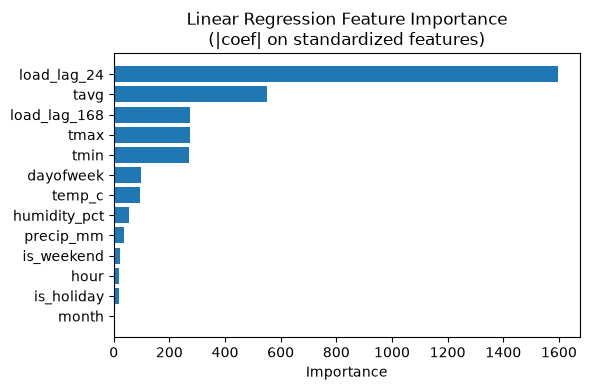

In [9]:
importance = np.abs(model.coef_) 
imp_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": importance,
    "coef": model.coef_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(6, 4))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.gca().invert_yaxis()
plt.title("Linear Regression Feature Importance\n(|coef| on standardized features)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Support Vector Regression (SVR)

In [ ]:
import numpy as np
# 1. Swap the scikit-learn import for cuML
from cuml.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

FEATURES = ["temp_c", "humidity_pct", "precip_mm", "tmax", "tmin", "tavg",
            "hour", "dayofweek", "month", "is_weekend", "is_holiday",
            "load_lag_24", "load_lag_168"]
TARGET = "actual_load_mw"

# Initialize OOF array with NaNs
oof_svr = np.full(len(train), np.nan)

for fold_id, (tr_start, tr_end, val_start, val_end) in enumerate(fold_boundaries, start=1):
    # Apply chronological boolean masking
    train_mask = (train["timestamp"] >= tr_start) & (train["timestamp"] <= tr_end)
    val_mask   = (train["timestamp"] >= val_start) & (train["timestamp"] <= val_end)

    X_train, y_train = train.loc[train_mask, FEATURES], train.loc[train_mask, TARGET]
    X_val,   y_val   = train.loc[val_mask,   FEATURES], train.loc[val_mask,   TARGET]

    # 2. Cast to float32 for maximum GPU acceleration
    X_train = X_train.astype('float32')
    y_train = y_train.astype('float32')
    X_val   = X_val.astype('float32')

    # Scale (fit strictly on THIS fold's train to prevent leakage)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)

    # 3. Initialize and fit the cuML SVR
    # The syntax and hyperparameter names map exactly to sklearn
    model = SVR(
        kernel="poly", 
        degree=2, 
        gamma="scale", 
        coef0=1.0, 
        C=1.0, 
        epsilon=0.1
    )
    model.fit(X_train_s, y_train)

    # Validation predictions execute directly on the GPU
    val_preds = model.predict(X_val_s)
    
    # 4. Safely pull predictions back to CPU memory (NumPy) for the OOF array
    if hasattr(val_preds, 'to_numpy'):
        val_preds = val_preds.to_numpy()
        
    oof_svr[val_mask.values] = val_preds

    rmse = mean_squared_error(y_val, val_preds) ** 0.5
    print(f"Fold {fold_id} RMSE: {rmse:.2f}")

# Calculate overall OOF score
valid = ~np.isnan(oof_svr)
oof_rmse = mean_squared_error(train.loc[valid, TARGET], oof_svr[valid]) ** 0.5
print("-" * 40)
print(f"cuML SVR Model, CV OOF RMSE: {oof_rmse:.2f}")